In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [2]:
df = pd.read_csv(r"D:\archive\HAM10000_metadata.csv")
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


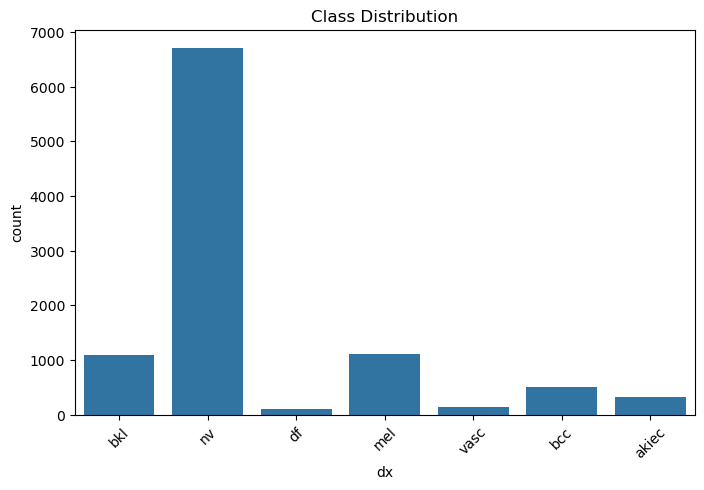

In [3]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='dx')
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()

In [4]:
import os

# Define both image directories
image_dir_1 = r"D:\archive\HAM10000_images_part_1"
image_dir_2 = r"D:\archive\HAM10000_images_part_2"

# Create empty dictionary
image_paths = {}

# Loop through both folders
for folder in [image_dir_1, image_dir_2]:
    for x in os.listdir(folder):
        image_id = os.path.splitext(os.path.basename(x))[0]
        image_paths[image_id] = os.path.join(folder, x)

# Map paths to dataframe
df['path'] = df['image_id'].map(image_paths.get)

In [5]:
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['dx'], random_state=42)

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)

In [7]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='path',
    y_col='dx',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    x_col='path',
    y_col='dx',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 8012 validated image filenames belonging to 7 classes.
Found 2003 validated image filenames belonging to 7 classes.


In [8]:
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['dx']),
    y=train_df['dx']
)

class_weights = dict(zip(range(len(weights)), weights))

In [9]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False   # Freeze base model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(7, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3)

checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)

In [12]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1553 - loss: 2.7655

251/251 ━━━━━━━━━━━━━━━━━━━━ 560s 2s/step - accuracy: 0.1855 - loss: 2.5615 - val_accuracy: 0.3195 - val_loss: 1.7715 - learning_rate: 1.0000e-04
Epoch 2/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2622 - loss: 2.2615

251/251 ━━━━━━━━━━━━━━━━━━━━ 398s 2s/step - accuracy: 0.2785 - loss: 2.1802 - val_accuracy: 0.4343 - val_loss: 1.5843 - learning_rate: 1.0000e-04
Epoch 3/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3319 - loss: 2.0331

251/251 ━━━━━━━━━━━━━━━━━━━━ 547s 2s/step - accuracy: 0.3372 - loss: 1.9404 - val_accuracy: 0.4848 - val_loss: 1.4920 - learning_rate: 1.0000e-04
Epoch 4/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3553 - loss: 1.8504

251/251 ━━━━━━━━━━━━━━━━━━━━ 562s 2s/step - accuracy: 0.3712 - loss: 1.8566 - val_accuracy: 0.5132 - val_loss: 1.4137 - learning_rate: 1.0000e-04
Epoch 5/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 543s 2s/step - accuracy: 0.3968 - loss: 1.7443 - val_accuracy: 0.5077 - val_loss: 1.4138 - learning_rate: 1.0000e-04
Epoch 6/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4069 - loss: 1.7399

...

251/251 ━━━━━━━━━━━━━━━━━━━━ 480s 2s/step - accuracy: 0.4209 - loss: 1.6269 - val_accuracy: 0.5287 - val_loss: 1.3561 - learning_rate: 1.0000e-04
Epoch 8/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 423s 2s/step - accuracy: 0.4415 - loss: 1.6024 - val_accuracy: 0.5127 - val_loss: 1.3622 - learning_rate: 1.0000e-04
Epoch 9/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4550 - loss: 1.4775

251/251 ━━━━━━━━━━━━━━━━━━━━ 424s 2s/step - accuracy: 0.4523 - loss: 1.5699 - val_accuracy: 0.5287 - val_loss: 1.3107 - learning_rate: 1.0000e-04
Epoch 10/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4566 - loss: 1.4925

251/251 ━━━━━━━━━━━━━━━━━━━━ 443s 2s/step - accuracy: 0.4596 - loss: 1.5098 - val_accuracy: 0.5452 - val_loss: 1.2982 - learning_rate: 1.0000e-04
Epoch 11/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4685 - loss: 1.4641

251/251 ━━━━━━━━━━━━━━━━━━━━ 402s 2s/step - accuracy: 0.4712 - loss: 1.4630 - val_accuracy: 0.5562 - val_loss: 1.2442 - learning_rate: 1.0000e-04
Epoch 12/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4652 - loss: 1.4749

251/251 ━━━━━━━━━━━━━━━━━━━━ 390s 2s/step - accuracy: 0.4747 - loss: 1.4536 - val_accuracy: 0.5617 - val_loss: 1.2192 - learning_rate: 1.0000e-04
Epoch 13/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 389s 2s/step - accuracy: 0.4745 - loss: 1.4512 - val_accuracy: 0.5342 - val_loss: 1.2886 - learning_rate: 1.0000e-04
Epoch 14/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 395s 2s/step - accuracy: 0.4820 - loss: 1.3998 - val_accuracy: 0.5327 - val_loss: 1.2811 - learning_rate: 1.0000e-04
Epoch 15/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 391s 2s/step - accuracy: 0.4777 - loss: 1.3620 - val_accuracy: 0.5387 - val_loss: 1.2579 - learning_rate: 1.0000e-04
Epoch 16/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 399s 2s/step - accuracy: 0.4886 - loss: 1.3377 - val_accuracy: 0.5427 - val_loss: 1.2522 - learning_rate: 3.0000e-05
Epoch 17/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 432s 2s/step - accuracy: 0.4838 - loss: 1.3313 - val_accuracy: 0.5367 - val_loss: 1.2655 - learning_rate: 3.0000e-05


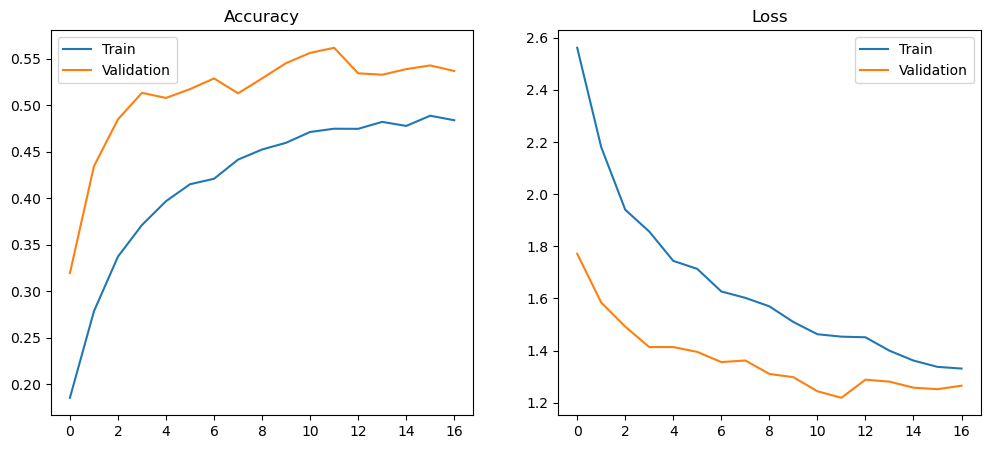

In [13]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.legend()
plt.title("Loss")

plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 57s 866ms/step


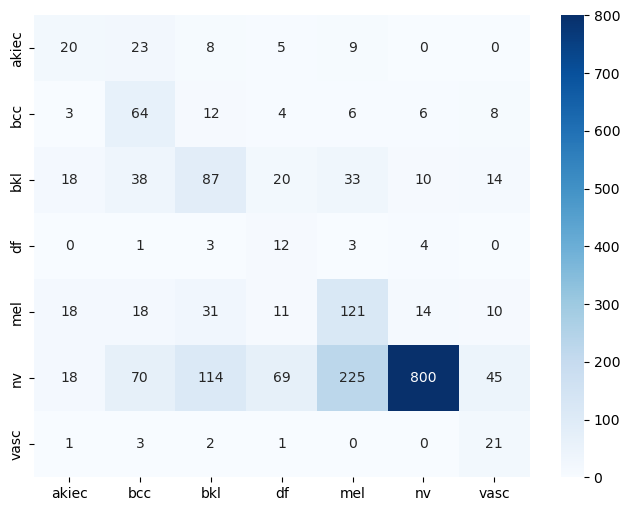

In [14]:
y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(val_generator.classes, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_generator.class_indices.keys(),
            yticklabels=train_generator.class_indices.keys())
plt.show()

In [15]:
from sklearn.metrics import classification_report
print(classification_report(val_generator.classes, y_pred_classes))

              precision    recall  f1-score   support

           0       0.26      0.31      0.28        65
           1       0.29      0.62      0.40       103
           2       0.34      0.40      0.36       220
           3       0.10      0.52      0.17        23
           4       0.30      0.54      0.39       223
           5       0.96      0.60      0.74      1341
           6       0.21      0.75      0.33        28

    accuracy                           0.56      2003
   macro avg       0.35      0.53      0.38      2003
weighted avg       0.74      0.56      0.61      2003



In [16]:
model.save("skin_disease_model.keras")

In [17]:
class_names = {
    0: "Actinic keratoses",
    1: "Basal cell carcinoma",
    2: "Benign keratosis",
    3: "Dermatofibroma",
    4: "Melanoma",
    5: "Melanocytic nevi",
    6: "Vascular lesions"
}

import numpy as np
np.save("class_names.npy", class_names)

In [18]:
import tensorflow as tf
print(tf.__version__)

2.20.0
